# Importing Pandas and loading the data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import locale

# Set the locale to German (Germany)
locale.setlocale(locale.LC_ALL, 'de_DE.UTF-8')

orders_df = pd.read_csv('../data/cleaned/orders_new.csv')
orderlines_df = pd.read_csv('../data/cleaned/order_lines_new.csv')
products_df = pd.read_csv('../data/cleaned/products_new.csv')
brands_df = pd.read_csv('../data/cleaned/brands_new.csv')

## Making copies

In [2]:
or_df = orders_df.copy()
ol_df = orderlines_df.copy()
pr_df = products_df.copy()
br_df = brands_df.copy()

# Analysing...

In [3]:
or_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46204 entries, 0 to 46203
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      46204 non-null  int64  
 1   created_date  46204 non-null  str    
 2   total_paid    46204 non-null  float64
 3   state         46204 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 1.4 MB


In [4]:
or_df['created_date'] = pd.to_datetime(or_df['created_date'])

In [5]:
ol_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61407 entries, 0 to 61406
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                61407 non-null  int64  
 1   id_order          61407 non-null  int64  
 2   product_quantity  61407 non-null  int64  
 3   sku               61407 non-null  str    
 4   unit_price        61407 non-null  float64
 5   date              61407 non-null  str    
dtypes: float64(1), int64(3), str(2)
memory usage: 2.8 MB


In [6]:
ol_df['date'] = pd.to_datetime(ol_df['date'])

In [7]:
pr_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5968 entries, 0 to 5967
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sku                  5968 non-null   str    
 1   name                 5968 non-null   str    
 2   desc                 5968 non-null   str    
 3   price                5968 non-null   float64
 4   promo_price          5968 non-null   float64
 5   in_stock             5968 non-null   int64  
 6   type                 5968 non-null   str    
 7   promo_price_suspect  5968 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(4)
memory usage: 332.3 KB


## Business definitions used in this notebook

The project question is about discounts. The dataset contains several price-related fields:

- `price`: product catalog price from the products table.
- `promo_price`: product-level promotional price. This field has data quality issues and is not necessarily historical.
- `unit_price`: actual transaction price in the order line.

For this reason, the notebook estimates the realized discount as:


realized discount = product catalog price - actual transaction unit price


This is not perfect, because product catalog prices may have changed over time. Therefore, rows where `unit_price` is much higher than `price` are not used for discount-size calculations.

## Product category classification

The original dataset does not contain clean business categories.  
The following rule-based classification keeps the project simple and transparent.

A product can match several keywords, but for this project we keep the first detected category to simplify the analysis.

In [8]:
pr_df["category"] = " "

# Main categories
pr_df.loc[
    pr_df["name"].str.contains(r"^.{0,7}apple iphone", case=False, na=False),
    "category"
] += ", smartphone"

pr_df.loc[
    pr_df["name"].str.contains(r"^.{0,7}apple ipad|tablet", case=False, na=False),
    "category"
] += ", tablet"

pr_df.loc[
    pr_df["name"].str.contains(r"imac|mac mini|mac pro", case=False, na=False),
    "category"
] += ", desktop"

pr_df.loc[
    pr_df["name"].str.contains(r"macbook", case=False, na=False),
    "category"
] += ", laptop"

# Accessories and components
pr_df.loc[
    pr_df["desc"].str.contains(
        r"cable|connector|lightning to usb|wall socket|power strip|charger|battery",
        case=False, na=False
    ),
    "category"
] += ", cable"

pr_df.loc[
    pr_df["desc"].str.contains(
        r"adapter|dock|hub|connection|expansion box",
        case=False, na=False
    ),
    "category"
] += ", adapter"

pr_df.loc[
    pr_df["desc"].str.contains(
        r"flash drive|hard drive|pendrive|hard disk|memory|storage|ssd|hardssd|modules|ssd expansion",
        case=False, na=False
    ) | pr_df["desc"].str.contains(r"^.{0,7}ram", case=False, na=False),
    "category"
] += ", storage"

pr_df.loc[
    pr_df["desc"].str.contains(r"refurbished|reconditioned|like new", case=False, na=False),
    "category"
] += ", refurbished"

pr_df.loc[
    pr_df["desc"].str.contains(r"monitor", case=False, na=False),
    "category"
] += ", monitor"

pr_df.loc[
    pr_df["desc"].str.contains(r"nas|server|raid|synology", case=False, na=False),
    "category"
] += ", server"

pr_df.loc[
    pr_df["desc"].str.contains(r"apple watch|smartwatch|smart watch", case=False, na=False),
    "category"
] += ", smartwatch"

pr_df.loc[
    pr_df["desc"].str.contains(r"keyboard", case=False, na=False),
    "category"
] += ", keyboard"

pr_df.loc[
    pr_df["desc"].str.contains(r"mouse|trackpad", case=False, na=False),
    "category"
] += ", mouse"

pr_df.loc[
    pr_df["desc"].str.contains(r"headset|headphones", case=False, na=False),
    "category"
] += ", headset"

pr_df.loc[
    pr_df["desc"].str.contains(r"camera", case=False, na=False),
    "category"
] += ", camera"

pr_df.loc[
    pr_df["desc"].str.contains(r"speaker|music system", case=False, na=False),
    "category"
] += ", speaker"

pr_df.loc[
    pr_df["desc"].str.contains(
        r"case|funda|housing|casing|folder|protect|cover|sleeve|screensaver|shell",
        case=False, na=False
    ),
    "category"
] += ", case"

# other
pr_df.loc[pr_df["category"] == " ", "category"] = ", other"

pr_df["category"] = (
    pr_df["category"]
    .str.lstrip(", ")
    .str.split(",")
    .str[0]
    .str.strip()
)

pr_df["category"].value_counts()

category
case           830
other          822
storage        787
laptop         700
cable          524
desktop        485
adapter        444
refurbished    210
server         208
tablet         199
smartphone     174
smartwatch     172
monitor        151
headset         86
speaker         78
camera          45
keyboard        37
mouse           16
Name: count, dtype: int64

## Build the analysis-ready sales table

This table combines product information with order-line transactions.  
It is the main table used for discount and revenue analysis.

In [9]:
pr_ol_merged = ol_df.merge(pr_df, on="sku", how="inner")

pr_ol_merged["row_total"] = (
    pr_ol_merged["product_quantity"] * pr_ol_merged["unit_price"]
).round(2)
pr_ol_merged['discount'] = (pr_ol_merged['price'] - pr_ol_merged['unit_price']).round(2)
pr_ol_merged['%'] = (pr_ol_merged['discount']/pr_ol_merged['price'] *100).round(2)
pr_ol_merged[['id','id_order','sku','name','price','unit_price','discount','%','date']]

,id,id_order,sku,name,price,unit_price,discount,%,date
0,1119116,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD...,60.99,47.49,13.50,22.13,2017-01-01 01:46:16
1,1119119,299546,IOT0014,iOttie Easy View 2 Car Black Support,22.95,18.99,3.96,17.25,2017-01-01 01:50:34
2,1119120,295347,APP0700,Apple 85W MagSafe 2 charger MacBook Pro screen...,89.00,72.19,16.81,18.89,2017-01-01 01:54:11
3,1119126,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",3209.00,2565.99,643.01,20.04,2017-01-01 02:07:42
4,1119134,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,76.99,60.90,16.09,20.90,2017-01-01 02:20:14
...,...,...,...,...,...,...,...,...,...
61402,1649474,525664,TUC0207,Tucano Elements Second Skin Macbook Sleeve 12 ...,24.99,16.52,8.47,33.89,2018-03-14 11:45:05
61403,1649512,527070,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,25.00,9.99,15.01,60.04,2018-03-14 11:49:01
61404,1649522,527074,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,25.00,9.99,15.01,60.04,2018-03-14 11:49:36
61405,1649565,527096,APP0698,Apple Lightning Cable Connector to USB 1m Whit...,25.00,9.99,15.01,60.04,2018-03-14 11:54:35


in some cases we have a negative discount, which means that unit_price > price !

- here we need to distinguish that:

    - in some cases the difference is between 0.01 and 0.99
        - I tend to consider this as pipeline noise because of rounding or somthing like this, so I won't consider these as discounted products

    - in other cases the difference is really big

In [10]:
# Classify discount quality.
# Small differences are treated as rounding/pipeline noise.
# Large negative differences suggest that the catalog price is not historical.
pr_ol_merged["disc_quality"] = "valid"
noise_mask = (abs(pr_ol_merged['discount']).between(0.01, 0.99))
large_neg_mask = pr_ol_merged['discount'] < -0.99

pr_ol_merged.loc[noise_mask, "disc_quality"] = "rounding_noise"
pr_ol_merged.loc[large_neg_mask, "disc_quality"] = "negative_price_mismatch"

pr_ol_merged

,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,promo_price,in_stock,type,promo_price_suspect,category,row_total,discount,%,disc_quality
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,49.99,1,12755395,False,desktop,47.49,13.50,22.13,valid
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,16.99,0,5720,False,other,18.99,3.96,17.25,valid
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,64.99,1,13005399,False,laptop,72.19,16.81,18.89,valid
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",IMac desktop computer 27 inch Retina 5K RAM 32...,3209.00,2667.99,0,1282,False,desktop,2565.99,643.01,20.04,valid
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,70.70,0,1298,False,storage,60.90,16.09,20.90,valid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61402,1649474,525664,1,TUC0207,16.52,2018-03-14 11:45:05,Tucano Elements Second Skin Macbook Sleeve 12 ...,velvety inner protective case for MacBook 12 i...,24.99,19.99,0,13835403,False,laptop,16.52,8.47,33.89,valid
61403,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.99,1,1230,False,cable,19.98,15.01,60.04,valid
61404,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.99,1,1230,False,cable,19.98,15.01,60.04,valid
61405,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.99,1,1230,False,cable,29.97,15.01,60.04,valid


In [11]:
# Analysis discount columns:
# - rounding noise is set to zero
# - negative price mismatch is set to NaN for discount-specific calculations
pr_ol_merged.loc[noise_mask, ["discount", "%"]] = 0.00
pr_ol_merged.loc[large_neg_mask, ["discount", "%"]] = np.nan

pr_ol_merged["is_discounted"] = np.where(
    pr_ol_merged["discount"].notna(),
    (pr_ol_merged["discount"] > 0).astype(int),
    np.nan
)
pr_ol_merged

,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,promo_price,in_stock,type,promo_price_suspect,category,row_total,discount,%,disc_quality,is_discounted
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,49.99,1,12755395,False,desktop,47.49,13.50,22.13,valid,1.0
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,16.99,0,5720,False,other,18.99,3.96,17.25,valid,1.0
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,64.99,1,13005399,False,laptop,72.19,16.81,18.89,valid,1.0
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",IMac desktop computer 27 inch Retina 5K RAM 32...,3209.00,2667.99,0,1282,False,desktop,2565.99,643.01,20.04,valid,1.0
4,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,70.70,0,1298,False,storage,60.90,16.09,20.90,valid,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61402,1649474,525664,1,TUC0207,16.52,2018-03-14 11:45:05,Tucano Elements Second Skin Macbook Sleeve 12 ...,velvety inner protective case for MacBook 12 i...,24.99,19.99,0,13835403,False,laptop,16.52,8.47,33.89,valid,1.0
61403,1649512,527070,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.99,1,1230,False,cable,19.98,15.01,60.04,valid,1.0
61404,1649522,527074,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.99,1,1230,False,cable,19.98,15.01,60.04,valid,1.0
61405,1649565,527096,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,9.99,1,1230,False,cable,29.97,15.01,60.04,valid,1.0


In [12]:
# Time features
pr_ol_merged["month"] = pr_ol_merged["date"].dt.to_period("M").dt.to_timestamp()
pr_ol_merged["month_label"] = pr_ol_merged["month"].dt.strftime("%Y-%m")

# Special-event flags based on typical campaign windows in the dataset.
black_friday_mask = (
    pr_ol_merged["date"].between("2017-11-20", "2017-11-26")
    | pr_ol_merged["date"].between("2018-11-19", "2018-11-25")
)

christmas_mask = (
    pr_ol_merged["date"].between("2017-12-01", "2017-12-25")
    | pr_ol_merged["date"].between("2018-12-01", "2018-12-25")
)

pr_ol_merged["event_period"] = "Baseline"
pr_ol_merged.loc[black_friday_mask, "event_period"] = "Black Friday week"
pr_ol_merged.loc[christmas_mask, "event_period"] = "Christmas period"


pr_ol_merged["disc_quality"].value_counts()
# discount_quality_summary = pr_ol_merged["disc_quality"].value_counts().rename_axis("discount_quality").reset_index(name="order_lines")
# discount_quality_summary

disc_quality
valid                      58435
rounding_noise              1838
negative_price_mismatch     1134
Name: count, dtype: int64

Discount data-quality note

Rows marked as `negative_price_mismatch` are **kept for revenue and sales-volume analysis**, because they are real completed transactions.  
However, they are excluded from discount-size calculations because the catalog price is probably not the historical price at the time of purchase.

## Overall sales overview

In [13]:
overview = pd.Series({
    "completed_orders": or_df["order_id"].nunique(),
    "order_lines": pr_ol_merged["id"].nunique(),
    "unique_products_sold": pr_ol_merged["sku"].nunique(),
    "product_revenue_from_order_lines": pr_ol_merged["row_total"].sum(),
    "total_paid_from_orders": or_df["total_paid"].sum(),
    "start_date": pr_ol_merged["date"].min().date(),
    "end_date": pr_ol_merged["date"].max().date(),
}, name="value")

overview

completed_orders                          46204
order_lines                               61407
unique_products_sold                       5968
product_revenue_from_order_lines    15376718.68
total_paid_from_orders              15573277.91
start_date                           2017-01-01
end_date                             2018-03-14
Name: value, dtype: object

## How many products are discounted?

improve it by distinguishing between:

    -Product-level discounting
    “How many unique products were ever discounted?”

vs

    -Order-line discounting
    “What percentage of purchases were discounted?”

These are VERY different metrics.

Useful metrics:

    -pct_discounted_products
    
    -pct_discounted_orderlines
    
    -pct_discounted_revenue

In [14]:
#-pct_discounted_products
total_products = pr_ol_merged['sku'].nunique()
discounted_products = pr_ol_merged.loc[pr_ol_merged['discount'] > 0, 'sku'].nunique()
pct_discounted_products = round(discounted_products/total_products *100, 2)

#-pct_discounted_orderlines
total_order_lines = pr_ol_merged.shape[0]
discounted_order_lines = pr_ol_merged.loc[pr_ol_merged['is_discounted'] == 1, 'is_discounted'].sum()
pct_discounted_orderlines = round(discounted_order_lines/total_order_lines *100, 2)

#-pct_discounted_revenue

total_revenue = pr_ol_merged['row_total'].sum()
discounted_revenue = pr_ol_merged.loc[pr_ol_merged['is_discounted'] == 1, 'row_total'].sum()
pct_discounted_revenue = round(discounted_revenue/total_revenue *100, 2)

print(f'we have {discounted_products} discounted products from {total_products} i.e. {pct_discounted_products}%')
print(f'{pct_discounted_orderlines}% our order lines were discounted')
print(f'{pct_discounted_revenue}% from our Total Revenue ({locale.currency(total_revenue, grouping=True)}) came from discounted order lines ')

we have 5658 discounted products from 5968 i.e. 94.81%
90.38% our order lines were discounted
92.66% from our Total Revenue (15.376.718,68 €) came from discounted order lines 


### Interpretation

Discounted order lines represent the majority of product revenue.  
However, this **does not prove** that discounts caused the revenue. Since discounts are extremely common in the dataset, there is only a small non-discounted comparison group.

## How large are the discounts?

Averages can be misleading because the dataset contains extreme values.  
The median and distribution are more informative.

One should analyze:

    -median

    -quartiles

    -distribution
    
    -outliers

In [15]:
pr_ol_merged.loc[pr_ol_merged['discount'] > 0,['discount','%']].describe()

,discount,%
count,55501.000000,55501.000000
mean,41.333815,22.339031
std,88.744479,16.306511
min,1.000000,0.040000
25%,8.000000,10.240000
50%,18.000000,18.750000
75%,40.000000,28.990000
max,1511.200000,99.800000


In [16]:
pct_med = pr_ol_merged.loc[pr_ol_merged['%'] > 0,'%'].median()
pct_mode = pr_ol_merged.loc[pr_ol_merged['%'] > 0,'%'].mode()
dis_med = pr_ol_merged.loc[pr_ol_merged['discount'] > 0,'discount'].median()
dis_mode = pr_ol_merged.loc[pr_ol_merged['discount'] > 0,'discount'].mode()

print(f'Median(%): {pct_med}\nMode(%): {pct_mode[0]}\n')
print(f'Median(discount)): {dis_med}\nMode(discount): {dis_mode[0]}')

Median(%): 18.75
Mode(%): 20.0

Median(discount)): 18.0
Mode(discount): 10.0


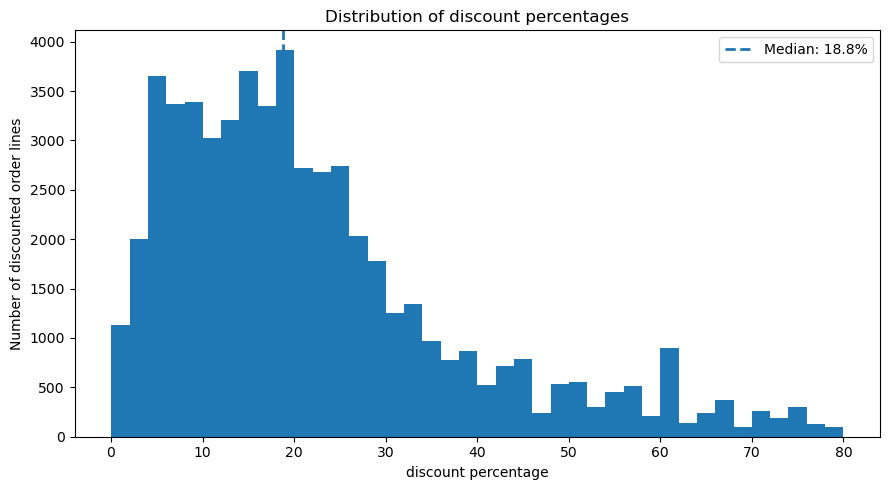

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

# Limit the x-axis to 0-80% to keep the main distribution readable.
ax.hist(
    pr_ol_merged.loc[pr_ol_merged['%'] > 0,'%'].clip(upper=80),
    bins=40
)

ax.axvline(pct_med, linestyle="--", linewidth=2, label=f"Median: {pct_med:.1f}%")
ax.set_title("Distribution of discount percentages")
ax.set_xlabel("discount percentage")
ax.set_ylabel("Number of discounted order lines")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation

The typical realized discount is moderate, but the distribution is wide

## Seasonality and special dates

Now we check how sales changed over time and around special events such as Black Friday and Christmas.

**Important:** March 2018 is only a partial month in this dataset, so it should not be compared directly with full months.

In [18]:
monthly = (
    pr_ol_merged
    .groupby("month", as_index=False)
    .agg(
        product_revenue=("row_total", "sum"),
        orders_count=("id_order", "nunique"),
        order_lines_count=("id", "count"),
        units_sold=("product_quantity", "sum"),
        median_discount_pct=("%", lambda x: x[x > 0].median()),
        avg_discount_pct=("%", lambda x: x[x > 0].mean()),
        pct_discounted_order_lines=("is_discounted", lambda x: x.mean(skipna=True) * 100),
    )
)

monthly["month_label"] = monthly["month"].dt.strftime("%Y-%m")
monthly["avg_order_value_product_revenue"] = (
    monthly["product_revenue"] / monthly["orders_count"]
)

monthly

,month,product_revenue,orders_count,order_lines_count,units_sold,median_discount_pct,avg_discount_pct,pct_discounted_order_lines,month_label,avg_order_value_product_revenue
0,2017-01-01,1152641.11,5086,6714,7613,22.930,27.059814,92.409140,2017-01,226.630183
1,2017-02-01,599841.97,2227,2883,3261,18.965,21.793528,92.741062,2017-02,269.349784
2,2017-03-01,115151.47,204,276,309,18.880,21.788036,85.823755,2017-03,564.467990
3,2017-04-01,423433.80,1608,2129,2399,17.215,20.128428,89.888728,2017-04,263.329478
4,2017-05-01,590381.95,1872,2489,2926,15.100,17.685611,87.983193,2017-05,315.374973
5,2017-06-01,629909.35,1577,2095,2453,16.670,19.356418,89.720559,2017-06,399.435225
6,2017-07-01,1021611.34,3388,4629,5165,20.000,26.012723,94.109802,2017-07,301.538176
7,2017-08-01,709111.19,2338,3068,3414,17.190,21.523383,92.179144,2017-08,303.298199
8,2017-09-01,853520.55,2187,2924,3238,17.200,21.015202,89.957717,2017-09,390.270027
9,2017-10-01,1069950.36,3118,4119,4592,17.900,22.523459,92.012859,2017-10,343.152777


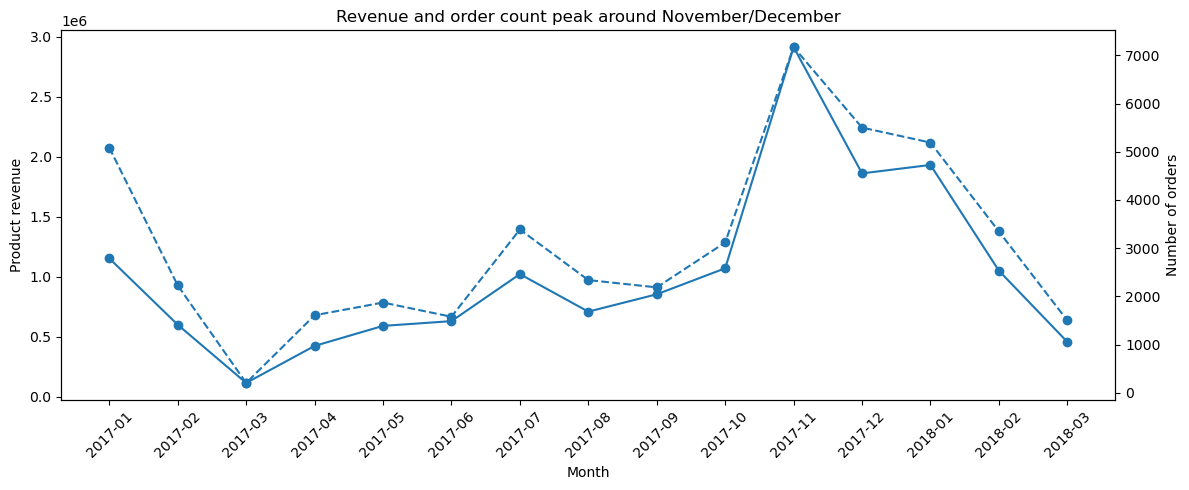

In [19]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly["month_label"], monthly["product_revenue"], marker="o", label="Product revenue")
ax1.set_ylabel("Product revenue")
ax1.set_xlabel("Month")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["month_label"], monthly["orders_count"], marker="o", linestyle="--", label="Orders")
ax2.set_ylabel("Number of orders")

ax1.set_title("Revenue and order count peak around November/December")
fig.tight_layout()
plt.show()

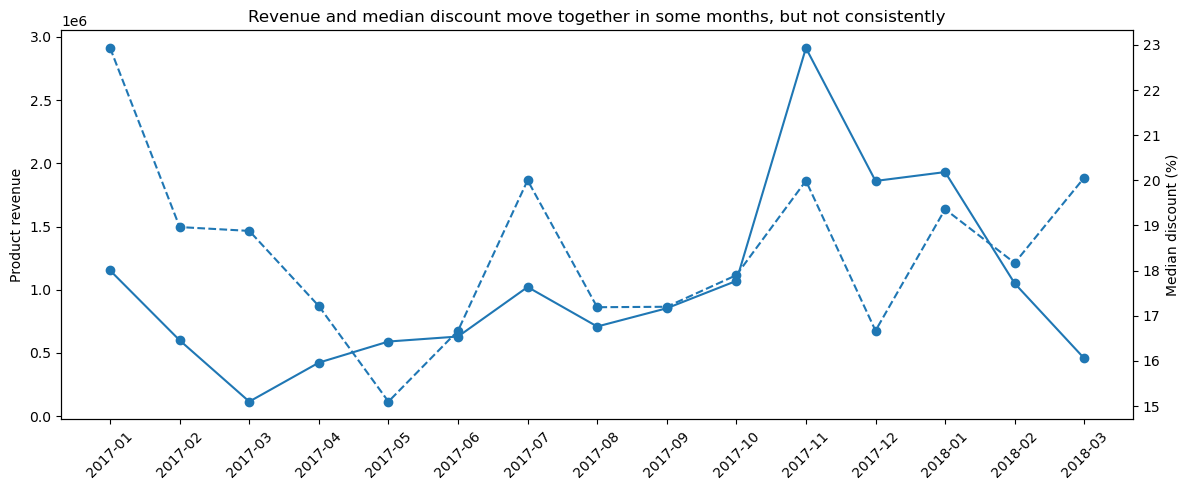

In [20]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly["month_label"], monthly["product_revenue"], marker="o")
ax1.set_ylabel("Product revenue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["month_label"], monthly["median_discount_pct"], marker="o", linestyle="--")
ax2.set_ylabel("Median discount (%)")

ax1.set_title("Revenue and median discount move together in some months, but not consistently")
fig.tight_layout()
plt.show()

### Interpretation

Revenue clearly changes by month, with a strong peak around November and high activity around December/January.  
Median discount percentage does not explain the revenue pattern by itself. With only 15 monthly observations and strong seasonality, this chart should be read as **correlation, not causation**.

## Black Friday and Christmas

To compare special periods fairly, we look at revenue and orders **per day**, because Black Friday week and Christmas period have different lengths.

In [22]:
event_summary = (
    pr_ol_merged
    .groupby("event_period")
    .agg(
        days=("date", lambda x: x.dt.date.nunique()),
        product_revenue=("row_total", "sum"),
        orders=("id_order", "nunique"),
        order_lines=("id", "count"),
        median_discount_pct=("%", lambda x: x[x > 0].median()),
        pct_discounted_order_lines=("is_discounted", lambda x: x.mean(skipna=True) * 100),
    )
    .reset_index()
)

event_summary["revenue_per_day"] = event_summary["product_revenue"] / event_summary["days"]
event_summary["orders_per_day"] = event_summary["orders"] / event_summary["days"]

event_summary = event_summary.set_index("event_period").loc[
    ["Baseline", "Black Friday week", "Christmas period"]
].reset_index()

event_summary

,event_period,days,product_revenue,orders,order_lines,median_discount_pct,pct_discounted_order_lines,revenue_per_day,orders_per_day
0,Baseline,408,12563941.77,38971,51719,18.87,91.608074,30793.974926,95.517157
1,Black Friday week,6,1572802.22,3547,4966,20.34,98.624595,262133.703333,591.166667
2,Christmas period,24,1239974.69,3745,4722,15.84,90.312966,51665.612083,156.041667


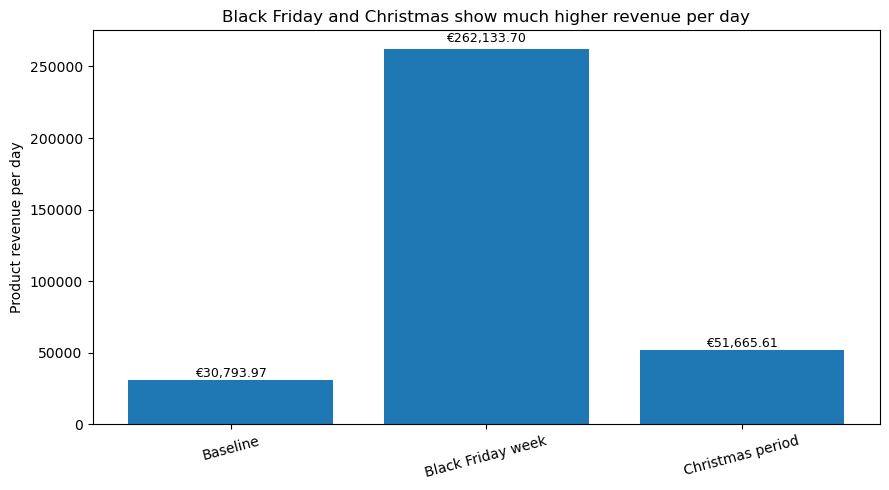

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(event_summary["event_period"], event_summary["revenue_per_day"])
ax.set_title("Black Friday and Christmas show much higher revenue per day")
ax.set_ylabel("Product revenue per day")
ax.tick_params(axis="x", rotation=15)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"€{height:,.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretation

Black Friday has very high revenue per day and a high share of discounted order lines.  
Christmas also has higher revenue per day than the baseline, but its median discount is not higher than the baseline.

This suggests that special-date demand and seasonality are important. Discounts may be part of the campaign mix, but this dataset alone cannot isolate the discount effect from Black Friday, Christmas, and customer demand.

# Final conclusion

The analysis does **not** provide strong evidence that discounts are the main cause of higher sales.

What we can say from the data:

1. Discounts are extremely common in the dataset.
2. Most product revenue comes from discounted order lines.
3. Revenue peaks around Black Friday, Christmas, and the winter season.
4. High-revenue periods often coincide with discount activity, but they also coincide with strong seasonal demand.
5. Very aggressive discounts do not dominate revenue; most revenue comes from low-to-moderate discount.
6. The relationship between discount size and revenue is not strong enough to conclude that higher discounts directly create higher revenue.

A careful business conclusion is:

> Discounts appear to be part of Eniac's sales strategy and are strongly present during high-sales periods. However, the current data does not prove that discounts caused the higher sales. Eniac should avoid aggressive across-the-board discounting and instead test targeted discounts by product category and season.

# Business recommendations

1. **Do not rely on company-wide aggressive discounts.**  
   Very high discounts contribute only a small share of revenue and may damage margin.

2. **Treat Black Friday as a special campaign, not as normal behavior.**  
   Black Friday performance should not be generalized to the rest of the year.

3. **Run controlled experiments.**  
   To measure whether discounts truly cause higher sales, Eniac should run A/B tests or controlled campaigns where similar products/customers are exposed to different discount levels.

4. **Include profitability before making final discount decisions.**  
   Revenue alone is not enough. The company needs cost and margin data to know whether discounts are profitable.

# Limitations

- Product catalog prices may not be historical, so the discount calculation is an approximation.
- `promo_price` is a product-level field and may not represent the actual promotion at the time of each order.
- Cost and margin data are not available, so profitability cannot be measured.
- Customer-level data is not available, so acquisition, retention, and customer lifetime value cannot be measured.
- March 2018 is incomplete and should not be compared directly with full months.
- Discounts are very common, which makes the non-discounted comparison group small.
- Seasonality, product mix, stock availability, and marketing campaigns may all affect revenue.

# Data collection improvements

To answer the board's question more confidently, Eniac should collect or improve the following fields:

- Historical product price by SKU and date.
- Promotion ID, campaign name, and discount rule.
- Clean product category taxonomy.
- Shipping fees and tax separation from product revenue.
- Clear distinction between catalog price, promotional price, coupon discount, and final transaction price.